In [80]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score
import plotly.graph_objects as go
from tensorflow.keras.callbacks import EarlyStopping

# Exercise 11

## Exercise 11.1: Parameter Space Exploration
To understand the dynamics of this Neural Network, I will systematically explore the parameter space by isolating three key variables:
1. **Dataset Size ($N_{\mathrm{train}}$):** How much information the network has to learn from.
2. **Training Duration ($N_{\mathrm{epochs}}$):** How long the network is allowed to search for the optimal weights.
3. **Data Noise ($\sigma$):** The amount of random variance obscuring the underlying mathematical truth.

I will proceed through a matrix of 4 trials (combining low/high data sizes with low/high epoch counts) before intentionally pushing a complex model to overfit the noise.

### Set up model

In [2]:
# Target parameters
m = 2 
q = 1 
sigma = 0.2 

def run_regression_trial(n_train, n_valid, epochs, batch_size, trial_name):
    """Generates data, trains a 1-neuron model, and plots the results side-by-side."""
    
    # Generate Data
    x_train = np.random.uniform(-1, 1, n_train)
    x_valid = np.random.uniform(-1, 1, n_valid)
    x_valid.sort()

    y_train = np.random.normal(m * x_train + q, sigma)
    y_valid = np.random.normal(m * x_valid + q, sigma)

    # Build and Train Model
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(1,))),
    model.add(tf.keras.layers.Dense(1))

    model.compile(
        optimizer='sgd', 
        loss='mse', 
        metrics=['mse'])
    
    # verbose=0 keeps the notebook clean by hiding the progress bar
    history = model.fit(x_train, 
                        y_train, 
                        batch_size=batch_size, 
                        epochs=epochs, 
                        validation_data=(x_valid, y_valid), 
                        shuffle=True, 
                        verbose=0) 

    # Plotting (side-by-side)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"{trial_name} (N={n_train}, Epochs={epochs})", fontsize=14, fontweight='bold')

    # Left Plot: Loss Curve
    ax1.plot(history.history['loss'], label='Training MSE')
    ax1.plot(history.history['val_loss'], label='Validation MSE')
    ax1.set_title('Model Loss over Time')
    ax1.set_ylabel('Loss (MSE)')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    # Right Plot: Predictions vs Target
    ax2.scatter(x_train, y_train, marker='.', c='b', alpha=0.3, label='Training data')
    ax2.scatter(x_valid, y_valid, marker='x', c='g', label='Validation data')
    
    x_plot = np.linspace(-1, 1, 100)
    ax2.plot(x_plot, m*x_plot + q, c='r', linewidth=2, label='Target function')
    ax2.plot(x_plot, model.predict(x_plot, verbose=0), c='orange', linewidth=2, label='Predicted function')
    
    ax2.set_title("Function Prediction")
    ax2.set_xlabel("x [a.u.]")
    ax2.set_ylabel("y [a.u.]")
    ax2.legend()

    plt.tight_layout()
    plt.show()

### Running the Parameter Matrix
We now execute the 4 configurations to observe how the network behaves under varying constraints.

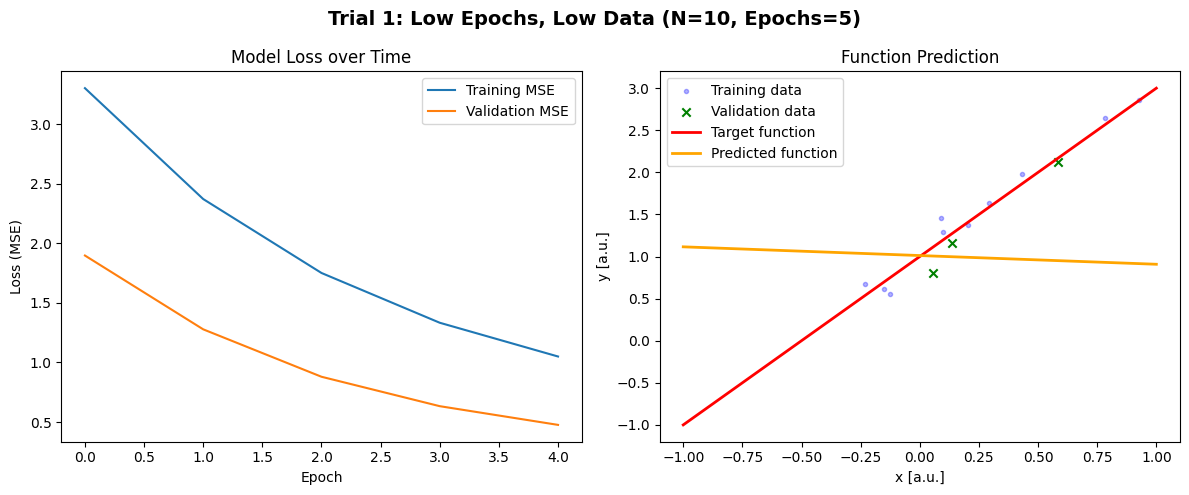

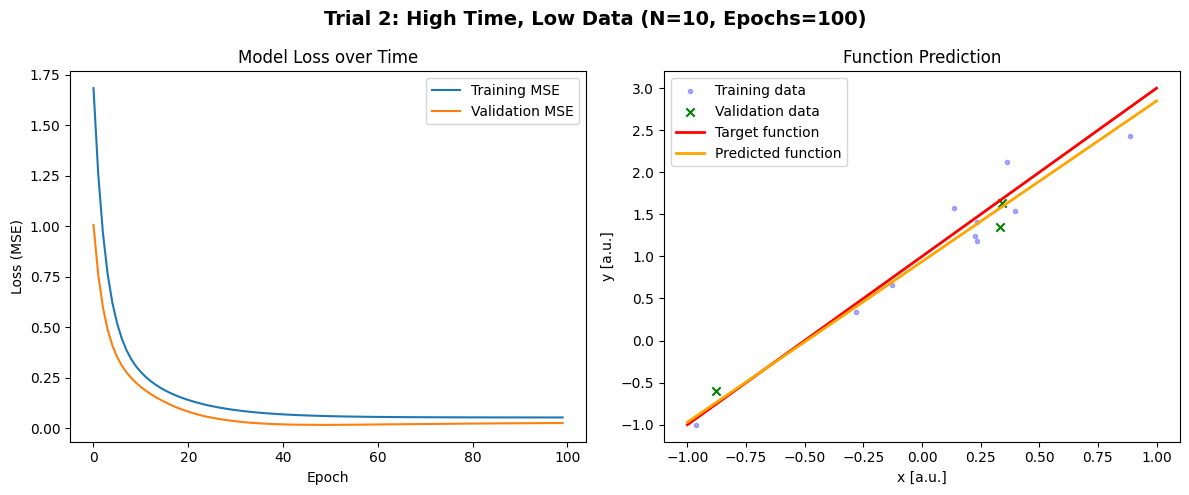

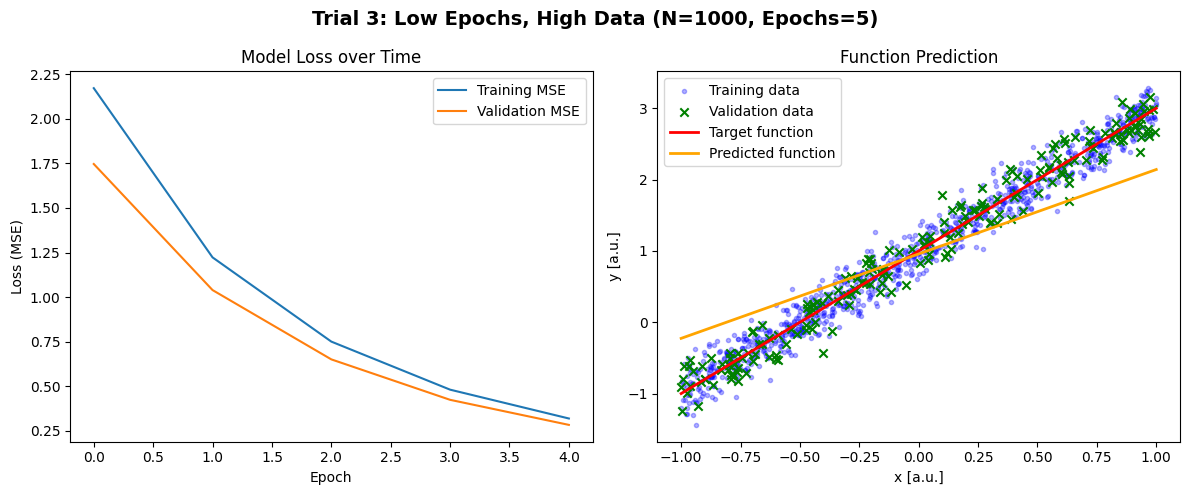

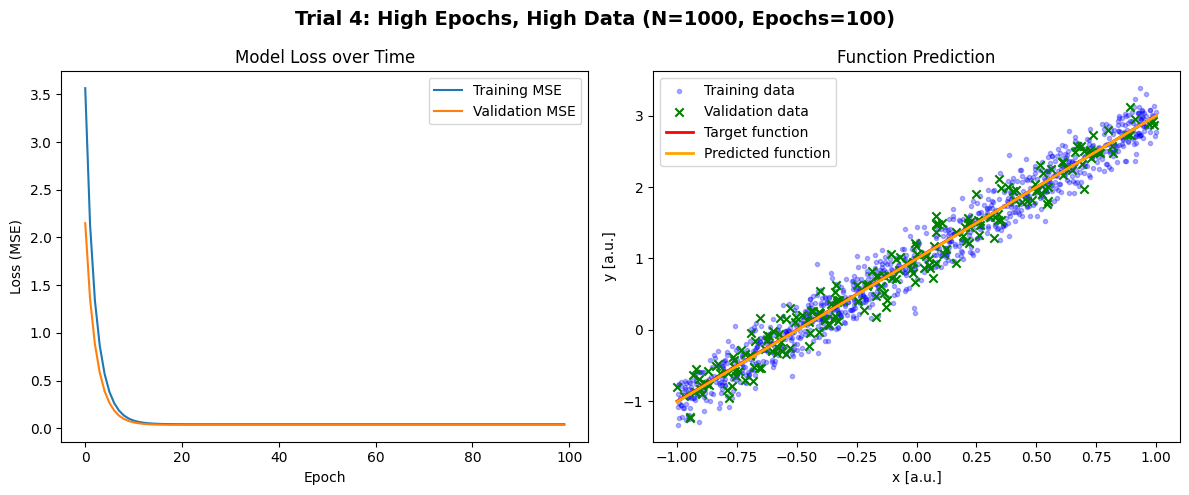

In [3]:
np.random.seed(0)
# tf.random.set_seed(0)

# Trial 1: Small dataset, small number of epochs
run_regression_trial(n_train=10, n_valid=3, epochs=5, batch_size=1, trial_name="Trial 1: Low Epochs, Low Data")

# Trial 2: Small dataset, big number of epochs
run_regression_trial(n_train=10, n_valid=3, epochs=100, batch_size=1, trial_name="Trial 2: High Time, Low Data")

# Trial 3: Big dataset, small number of epochs
run_regression_trial(n_train=1000, n_valid=200, epochs=5, batch_size=32, trial_name="Trial 3: Low Epochs, High Data")

# Trial 4: Big dataset, big number of epochs
run_regression_trial(n_train=1000, n_valid=200, epochs=100, batch_size=32, trial_name="Trial 4: High Epochs, High Data")

By systematically isolating dataset size ($N_{\mathrm{train}}$) and training duration ($N_{\mathrm{epochs}}$), we can observe how the network navigates its parameter space across four distinct scenarios:

* **Trial 1 (Low Data, Low Epochs):** The model fails to approximate the target function entirely. With only 10 noisy data points, the network lacks a clear mathematical representation of the underlying trend. Furthermore, stopping after just 5 epochs means the optimizer has barely begun its descent down the loss gradient; the final weights essentially remain in their randomized initial state. Running the code multiple times without the `tf.random.set_seed()` produces very variable results.
* **Trial 2 (Low Data, High Epochs):** The model successfully minimizes its loss, but the resulting prediction is poor. Because the dataset is so small, the optimizer converges on a "false" minimum dictated by the specific random placement of those few noisy points. The network has over-optimized for an unrepresentative sample, proving that ample training time cannot fix a fundamentally impoverished dataset.
* **Trial 3 (High Data, Low Epochs):** The prediction is highly unstable. While the dense dataset of 1000 points provides a smooth, accurate loss landscape pointing directly toward the true target function, the optimizer is prematurely halted. Gradient descent is an iterative process; giving the network a perfect map is useless if we do not give it enough time to walk to the destination.
* **Trial 4 (High Data, High Epochs):** The model achieves a near-perfect fit. The massive volume of data effectively "cancels out" the random noise ($\sigma$), providing a true gradient. Given an adequate number of epochs, the optimizer reliably traces this gradient down to the absolute global minimum, perfectly recovering the original parameters ($m=2$, $q=1$).

**Conclusion:** Data quantity and training duration are strictly complementary in deep learning. An abundance of high-quality data defines the correct path to the solution, but the network still requires sufficient epochs to travel that path.

### Overfitting
A single-neuron linear model cannot overfit data because its mathematical capacity is restricted to drawing a straight line. To observe overfitting, we must introduce **non-linearity** and **excess capacity**.

In this test, I will define a highly complex, multi-layer network with `relu` activations. We will train this same architecture on two different datasets (sparse vs. dense) to observe how data quantity interacts with model complexity.

In [4]:
sigma = 0.4 # Higher noise to encourage overfitting

def run_complex_model_trial(n_train, n_valid, batch_size, title):
    """Trains a highly over-parameterized model and plots the results."""
    
    # Generate Data
    np.random.seed(0)
    tf.random.set_seed(0)
    
    x_train = np.random.uniform(-1, 1, n_train)
    x_valid = np.random.uniform(-1, 1, n_valid)
    x_valid.sort()

    y_train = np.random.normal(m * x_train + q, sigma)
    y_valid = np.random.normal(m * x_valid + q, sigma)

    # Build Complex Model (massive capacity, non-linear activations)
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(1,))),
    model.add(tf.keras.layers.Dense(64, activation='relu')),
    model.add(tf.keras.layers.Dense(128, activation='relu')),
    model.add(tf.keras.layers.Dense(64, activation='relu')),
    model.add(tf.keras.layers.Dense(1)) # Linear output

    model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

    # Train for thousands of epochs
    history = model.fit(x_train, 
                        y_train, 
                        batch_size=batch_size, 
                        epochs=2000, 
                        validation_data=(x_valid, y_valid), 
                        shuffle=True, 
                        verbose=0)

    # Plotting (side-by-side)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Loss Curve
    ax1.plot(history.history['loss'], label='Training MSE')
    ax1.plot(history.history['val_loss'], label='Validation MSE')
    ax1.set_title('Model Loss over Time')
    ax1.set_ylabel('Loss (MSE)')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    # Prediction Plot
    ax2.scatter(x_train, y_train, marker='.', c='b', alpha=0.3, label='Training data')
    ax2.scatter(x_valid, y_valid, marker='x', c='g', alpha=0.3, label='Validation data')

    # Use high resolution (300 points) to properly see the wiggles
    x_plot = np.linspace(-1, 1, 300) 
    ax2.plot(x_plot, m*x_plot + q, c='r', linewidth=2, linestyle='--', label='Target function')
    ax2.plot(x_plot, model.predict(x_plot, verbose=0), c='orange', linewidth=2, label='Predicted function')

    ax2.set_title("Function Prediction")
    ax2.set_xlabel("x [a.u.]")
    ax2.set_ylabel("y [a.u.]")
    ax2.legend()

    plt.tight_layout()
    plt.show()

#### Scenario A: Sparse Data ($N=15$)
By using a small dataset with high noise, I expect the network to stop generalizing the core function ($y = 2x + 1$) and instead begin weaving its predictions through the random noise fluctuations.

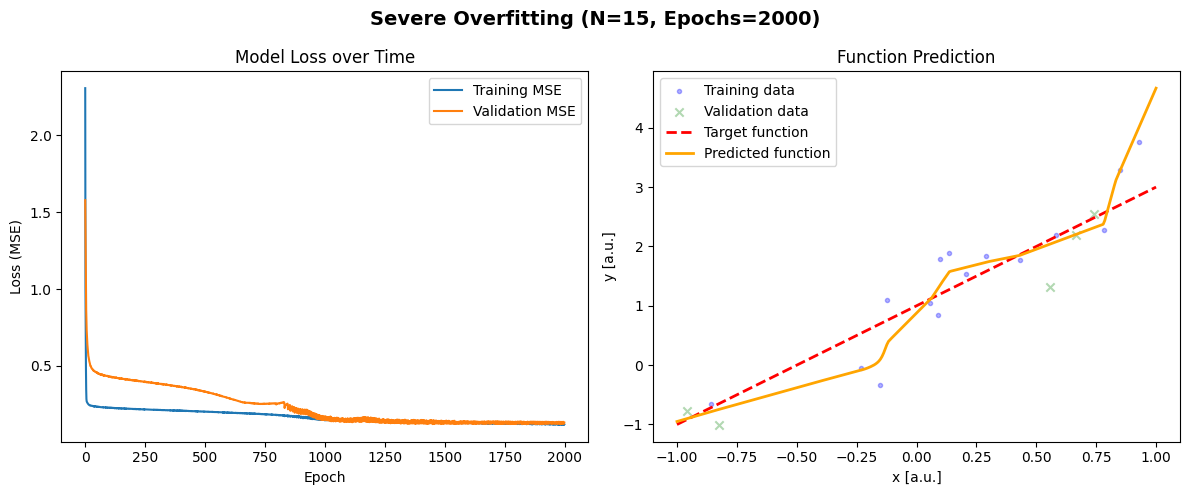

In [5]:
# Train the massive network on just 15 points
run_complex_model_trial(n_train=15, n_valid=5, batch_size=1, 
                        title="Severe Overfitting (N=15, Epochs=2000)")

#### Scenario B: The Effect of Increasing Data Density ($N=1000$)
What happens if we use the exact same over-parameterized network, but flood it with data? If noise is unavoidable, increasing the density of data should improve the quality of the prediction by providing conflicting gradients that "soften" the extreme wiggles of overfitting.

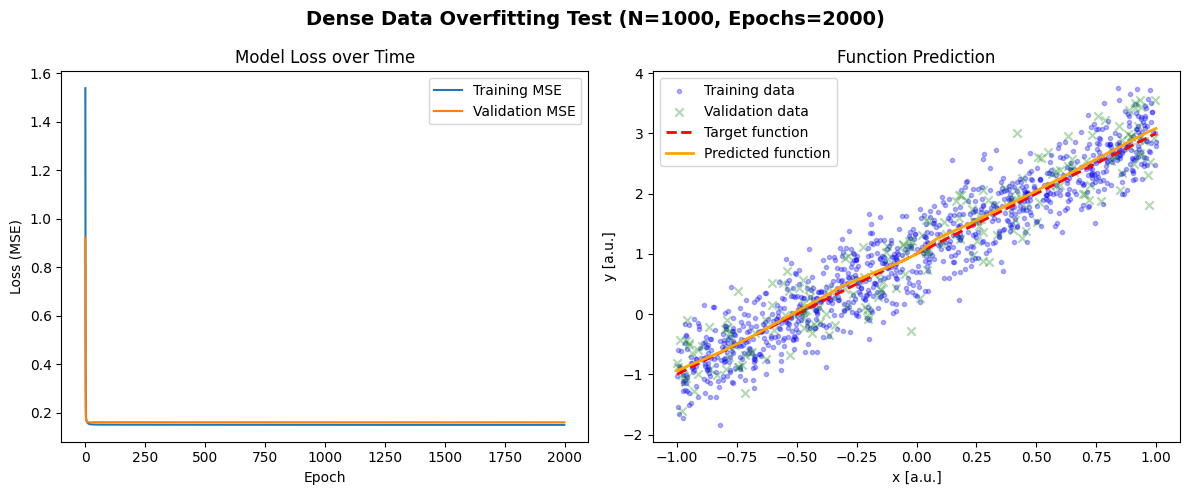

In [6]:
# Train the exact same network on 1000 points
run_complex_model_trial(n_train=1000, n_valid=200, batch_size=32, 
                        title="Dense Data Overfitting Test (N=1000, Epochs=2000)")

### Limits of Over-Parameterization and Epochs

The previous tests explicitly demonstrate that this complex architecture is an absolute overkill for this kind of linear problem. By granting the network massive mathematical capacity, we allowed it to abandon the search for the underlying physical law and instead memorize the random variance of our specific dataset.

From these experiments, we can extract critical guidelines for building models when the underlying true function is unknown:

* **More epochs can be dangerous:** In highly complex models, simply increasing the training time ($N_{\mathrm{epochs}}$) is not necessarily the best option. Without early stopping, an over-parameterized model will eventually perfectly fit the training data at the cost of generalization.
* **Data Quality over Training Time:** Improving the quality of the data (reducing the variance/noise, $\sigma$) provides a much cleaner gradient for the network to follow, leading to a faster and more stable convergence.
* **Data Quantity Smooths Complexity:** When noise is unavoidable, increasing the sheer quantity of data ($N_{\mathrm{train}}$) is the best defense against overfitting. A dense dataset forces the network to find the general trend, as it becomes mathematically impossible to weave a path through thousands of conflicting noisy points without incurring massive penalties.

Ultimately, the goal of machine learning is not to minimize the training error to zero, but to discover the simplest model that captures the true underlying mechanics of the system.

## Exercise 11.2: Fitting a Polynomial

In this exercise, we extend our neural network to fit a 3rd-order polynomial:
$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$. 

Fitting a cubic function requires more architectural care than a simple line. We must select appropriate hyperparameters:
* **Hidden Layers:** We will use two hidden layers to give the network enough capacity to bend and map the non-linear curves.
* **Activation Function:** We use `tanh` because it is naturally smooth and continuously differentiable, avoiding the jagged, piecewise straight lines produced by `relu`.
* **Loss Function:** We use Mean Absolute Error (`mae`). Unlike MSE, which squares small errors into insignificance, MAE applies a constant penalty. This prevents the optimizer from getting "lazy" and forces it to perfectly trace subtle local minima.
* **Optimizer:** We switch to `adam`, which adapts its learning rate dynamically and navigates the complex loss landscapes of polynomials much faster than standard `sgd`.

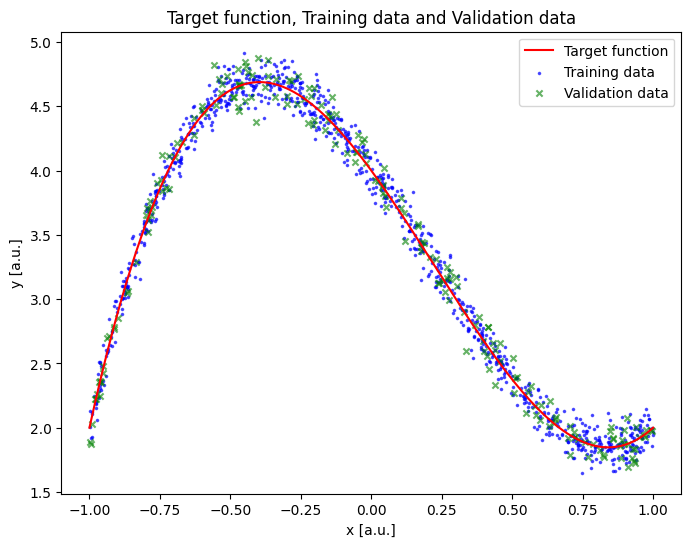

In [60]:
# First plot the function and generate the dataset
x = np.linspace(-1, 1, 1000)
y = 4 - 3*x - 2*x**2 + 3*x**3

sigma = 0.1

np.random.seed(0)
tf.random.set_seed(0)

x_train = np.random.uniform(-1, 1, 1000)
x_valid = np.random.uniform(-1, 1, 200)
y_train = np.random.normal((4 - 3*x_train - 2*x_train**2 + 3*x_train**3), sigma)
y_valid = np.random.normal((4 - 3*x_valid - 2*x_valid**2 + 3*x_valid**3), sigma)

plt.figure(figsize=(8,6))
plt.plot(x, y, c='r', label='Target function')
plt.scatter(x_train, y_train, marker='.', c='b', alpha=0.6, s=10, label='Training data')
plt.scatter(x_valid, y_valid, marker='x', c='g', alpha=0.6, s=20, label='Validation data')

plt.title("Target function, Training data and Validation data")
plt.xlabel("x [a.u.]")
plt.ylabel("y [a.u.]")
plt.legend()
plt.show()

### Model Compilation and Training
We construct the Sequential model and train it for 2000 epochs. This extended training duration ensures that the `adam` optimizer has enough time to fully minimize the Mean Absolute Error and accurately map the primary, global curves of the polynomial. However, as we will observe in the results, neural networks naturally struggle at the absolute boundaries of their training data.

In [61]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(1,)))

# Smooth activations to prevent jagged lines
model.add(tf.keras.layers.Dense(32, activation='tanh'))
model.add(tf.keras.layers.Dense(32, activation='tanh'))
model.add(tf.keras.layers.Dense(1)) # Linear output

model.compile(
    optimizer = 'adam',
    loss = 'mae',
    metrics = ['mse']
)

history = model.fit(
    x = x_train,
    y = y_train,
    batch_size = 32,
    epochs = 2000, 
    shuffle=True,
    validation_data=(x_valid, y_valid),
    verbose=0 # Set to 0 for clean notebook output
)

### Quantitative and Visual Evaluation

To rigorously evaluate the model, we calculate standard error metrics alongside the **$R^2$ Score (Coefficient of Determination)**. 

The $R^2$ score represents the proportion of the variance in our target variable ($y$) that the model can successfully predict from the input ($x$). 
* An $R^2$ of **1.0** indicates a flawless, perfect prediction. 
* An $R^2$ of **0.0** means the model is no better than drawing a flat horizontal line through the average of all $y$ values.
* An $R^2$ close to **0.95 or higher** is generally considered an excellent fit for noisy regression data.

Validation MAE (Average absolute error): 0.0815
Validation MSE (Mean squared error):     0.0103
R-squared Score: 0.9907


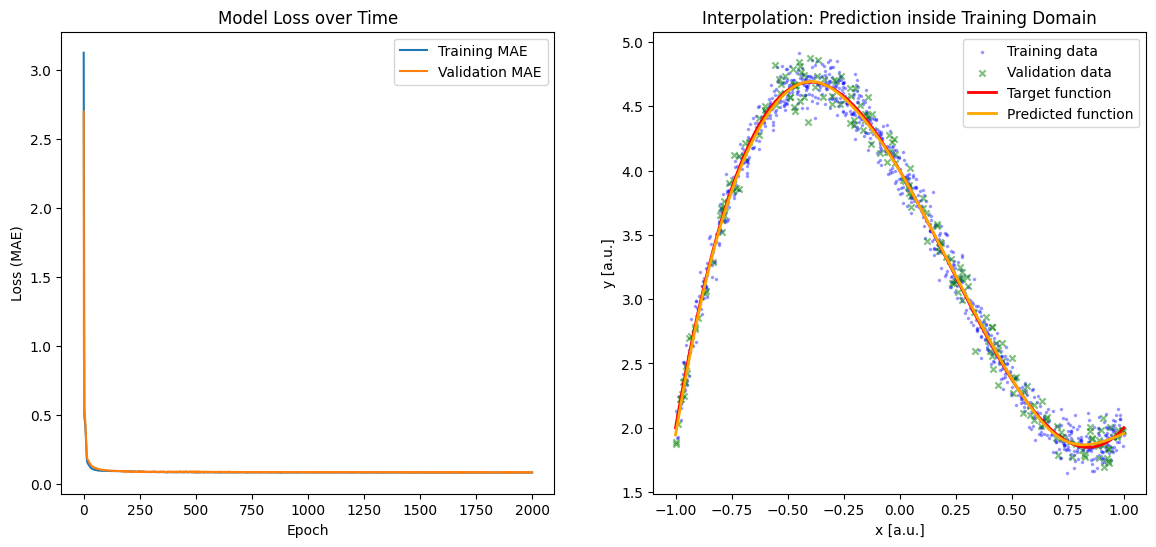

In [64]:
# Quantitative Evaluation
scores = model.evaluate(x_valid, y_valid, verbose=0)
print(f"Validation MAE (Average absolute error): {scores[0]:.4f}")
print(f"Validation MSE (Mean squared error):     {scores[1]:.4f}")

y_valid_pred = model.predict(x_valid, verbose=0)
r2 = r2_score(y_valid, y_valid_pred)
print(f"R-squared Score: {r2:.4f}")

# Visual Evaluation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Loss Plot
ax1.plot(history.history['loss'], label='Training MAE')
ax1.plot(history.history['val_loss'], label='Validation MAE')
ax1.set_title('Model Loss over Time')
ax1.set_ylabel('Loss (MAE)')
ax1.set_xlabel('Epoch')
ax1.legend()

# Prediction Plot
ax2.scatter(x_train, y_train, marker='.', c='b', alpha=0.3, s=10, label='Training data')
ax2.scatter(x_valid, y_valid, marker='x', c='g', alpha=0.5, s=20, label='Validation data')
ax2.plot(x, y, c='r', linewidth=2, label='Target function')

y_model = model.predict(x, verbose=0)
ax2.plot(x, y_model, c='orange', linewidth=2, label='Predicted function')

ax2.set_title("Interpolation: Prediction inside Training Domain")
ax2.set_xlabel("x [a.u.]")
ax2.set_ylabel("y [a.u.]")
ax2.legend()
plt.show()

### The Danger of Extrapolation

Inside the bulk of the $x \in [-1, 1]$ range, the interpolation is highly accurate, successfully mapping the main peaks and valleys. However, looking closely at the extreme boundaries ($x=-1.0$ and $x=1.0$), we observe an **edge effect**: the predicted curve begins to flatten out, diverging from the true polynomial. 

This occurs because there is no training data beyond those edges to guide the network, and the `tanh` activation function naturally plateaus at its extremes.

This edge flattening is the perfect transition to the problem of **extrapolation**. A neural network does not learn the abstract mathematical equation of $x^3$. It only learns to map specific input ranges to specific output ranges. When we input values outside the safe $[-1, 1]$ zone, the nodes quickly saturate, causing the network's prediction to completely flatline and fail to capture the aggressive vertical growth of the cubic function.

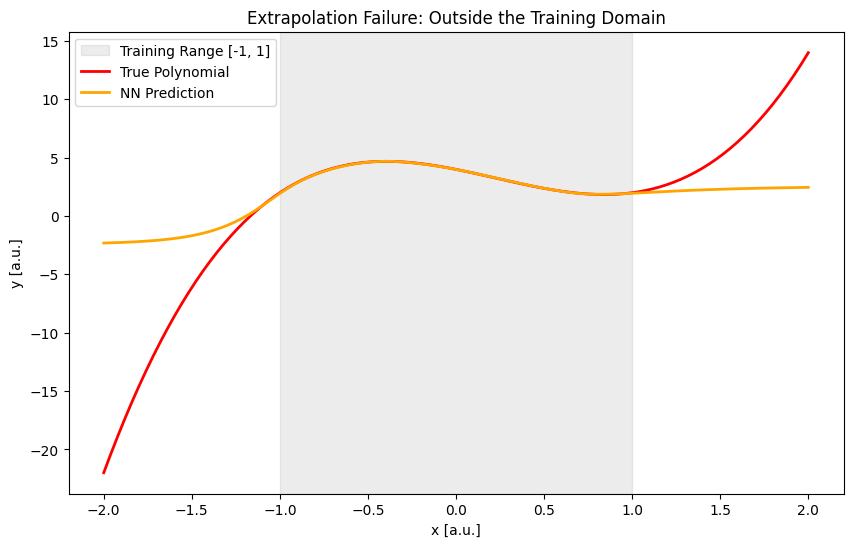

In [65]:
# Generate data outside the training range
x_extrap = np.linspace(-2, 2, 200) # Expanded to [-2, 2]
y_extrap_target = 4 - 3*x_extrap - 2*x_extrap**2 + 3*x_extrap**3
y_extrap_pred = model.predict(x_extrap, verbose=0)

plt.figure(figsize=(10,6))

# Highlight the safe training zone
plt.axvspan(-1, 1, color='gray', alpha=0.15, label='Training Range [-1, 1]')

plt.plot(x_extrap, y_extrap_target, c='r', linewidth=2, label='True Polynomial')
plt.plot(x_extrap, y_extrap_pred, c='orange', linewidth=2, label='NN Prediction')

plt.title("Extrapolation Failure: Outside the Training Domain")
plt.xlabel("x [a.u.]")
plt.ylabel("y [a.u.]")
plt.legend()
plt.show()

## Exercise 11.3: Fitting a 2D Surface

In this final exercise, we extend our network to accept two inputs and predict a single output, modeling the trigonometric 2D function:
$$f(x,y) = \sin(x^2+y^2)$$ 
for $x \in [-1.5, 1.5]$ and $y \in [-1.5, 1.5]$.

In [145]:
# Generate Meshgrid for Mathematical Plotting
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(X**2 + Y**2)

# Generate Random Pairs for Neural Network Training
n_train = 5000
n_valid = 500
sigma = 0.1 

np.random.seed(0)
tf.random.set_seed(0)

x_train = np.random.uniform(-1.5, 1.5, n_train)
y_train = np.random.uniform(-1.5, 1.5, n_train)
x_valid = np.random.uniform(-1.5, 1.5, n_valid)
y_valid = np.random.uniform(-1.5, 1.5, n_valid)

# Calculate target Z and inject noise
z_train = np.sin(x_train**2 + y_train**2) + np.random.normal(0, sigma, n_train)
z_valid = np.sin(x_valid**2 + y_valid**2) + np.random.normal(0, sigma, n_valid)

# Stack x and y into a single (N, 2) array for Keras
inputs_train = np.column_stack((x_train, y_train))
inputs_valid = np.column_stack((x_valid, y_valid))

print("Training input shape:", inputs_train.shape)

Training input shape: (5000, 2)


### Modeling the 3D Geometry

Because this function resembles a wavy bowl, it contains complex, non-linear curvature in multiple directions. We adapt our network by:
1. **Input Shape:** Changing the input to `(2,)` to accept the `[x, y]` coordinate pairs.
2. **Architecture:** Using four hidden layers of 64 `swish` neurons. The `swish` activation function provides the smoothness needed to accurately map the 3D ripples without suffering from the "vanishing gradient" (flat-plane) problem that plagues deep `tanh` networks.

The `swish` activation function is defined as
$$f(x) = x * sigmoid(x)$$

In [142]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Input(shape=(2,)))
model.add(tf.keras.layers.Dense(64, activation='swish'))
model.add(tf.keras.layers.Dense(64, activation='swish'))
model.add(tf.keras.layers.Dense(64, activation='swish'))
model.add(tf.keras.layers.Dense(64, activation='swish'))
model.add(tf.keras.layers.Dense(1))

model.compile(
    optimizer = 'adam',
    loss = 'mae',
    metrics = ['mse']
)

history = model.fit(
    x = inputs_train,
    y = z_train,
    batch_size = 32,
    epochs = 1500,
    shuffle=True,
    validation_data=(inputs_valid, z_valid),
    verbose=0 
)

### Visualizing the Prediction and Metrics

To evaluate the model's performance visually, we pass the flattened mathematical meshgrid through the network and reshape the predictions back into a 2D grid. We then plot the model's training loss alongside a static 3D projection of the prediction wireframe overlapping the true mathematical surface.

In [167]:
# Quantitative Metrics
scores = model.evaluate(inputs_valid, z_valid, verbose=0)
val_mae = scores[0]
val_mse = scores[1]

# Generate predictions and calculate R-squared
z_valid_pred = model.predict(inputs_valid, verbose=0)
r2 = r2_score(z_valid, z_valid_pred)

print(f"Validation MAE (Average absolute error): {val_mae:.4f}")
print(f"Validation MSE (Mean squared error):     {val_mse:.4f}")
print(f"R-squared Score: {r2:.4f}")


# Generate 3D Surface Data
grid_points = np.column_stack((X.flatten(), Y.flatten()))
z_pred_flat = model.predict(grid_points, verbose=0)
Z_pred = z_pred_flat.reshape(X.shape)

Validation MAE (Average absolute error): 0.0790
Validation MSE (Mean squared error):     0.0106
R-squared Score: 0.9322


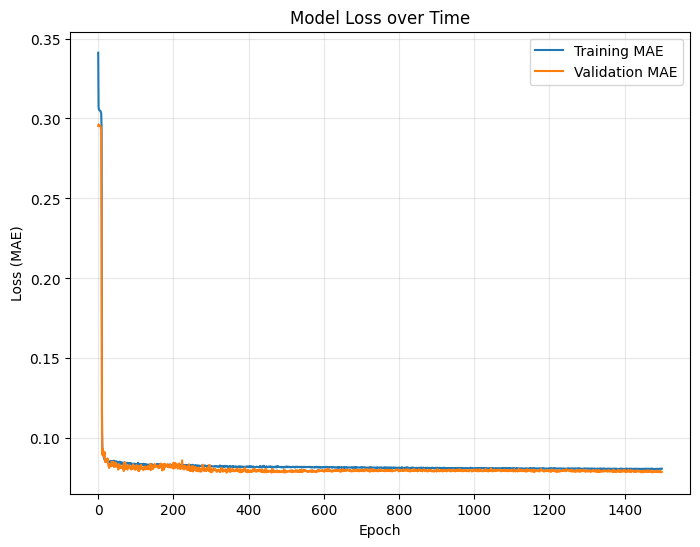

In [168]:
# Model loss over time
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training MAE')
plt.plot(history.history['val_loss'], label='Validation MAE')
plt.title('Model Loss over Time')
plt.ylabel('Loss (MAE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

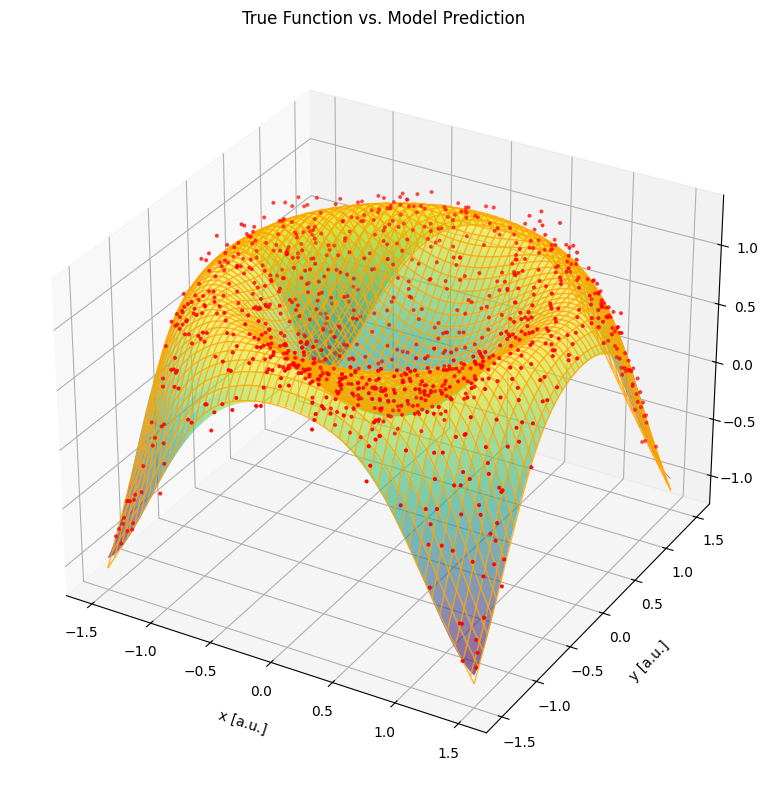

In [173]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# True surface
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)

# Model's prediction
ax.plot_wireframe(X, Y, Z_pred, color='orange', alpha=0.8, linewidth=1.0)

# Subset of the noisy training data
ax.scatter(x_train[:1000], y_train[:1000], z_train[:1000], 
            c='red', marker='.', s=15, label='Training Data')

ax.set_title("True Function vs. Model Prediction")
ax.set_xlabel("x [a.u.]", labelpad=10)
ax.set_ylabel("y [a.u.]", labelpad=10)
ax.set_zlabel("z [a.u.]", labelpad=10)

plt.tight_layout() 
plt.show()